In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
import coulomb as cb
    
exp_data = pd.read_csv(f'../data/goshtasbi_et_al_2020/Goshtasbi2020-tn.csv', sep=';', decimal=',')
exp_data['case'] = exp_data[['T_stack', 'rh_ca', 'rh_an', 'st_ca', 'st_an', 'p_ca_out']].sum(axis=1)
case_list = [1,2,3,4,5,6]
exp_data['case'] = exp_data['case'].map(dict(zip(exp_data['case'].unique(),case_list)))
exp_data = exp_data[::2]

In [2]:
def compute_ui_curve(fuel_cell, case): 
        current_density = np.maximum(1,1e4*exp_data.loc[exp_data.case == case, 'i'].values)
        cathode_conditions = cb.OperatingConditions(
            inlet_temperature = exp_data.loc[exp_data.case == case, 'T_stack'].values,
            inlet_relative_humidity=exp_data.loc[exp_data.case == case, 'rh_ca'].values,
            outlet_pressure=exp_data.loc[exp_data.case == case, 'p_ca_out'].values,
            dry_o2_mole_fraction=0.21,
            dry_h2_mole_fraction=0,
            stoichiometry=np.maximum(1, .1e4 / (current_density+1e-4)) *  exp_data.loc[exp_data.case == case, 'st_ca'].values,
        )
        anode_conditions = cb.OperatingConditions(
            inlet_temperature = exp_data.loc[exp_data.case == case, 'T_stack'].values,
            inlet_relative_humidity=exp_data.loc[exp_data.case == case, 'rh_an'].values,
            outlet_pressure=exp_data.loc[exp_data.case == case, 'p_an_out'].values + .1e5,
            dry_o2_mole_fraction=0,
            dry_h2_mole_fraction=1,
            stoichiometry=np.maximum(1, .1e4 / (current_density+1e-4)) * exp_data.loc[exp_data.case == case, 'st_an'].values,
        )

        fuel_cell.set_conditions(exp_data.loc[exp_data.case == case, 'T_stack'].values, 
                                 current_density,cathode_conditions, anode_conditions)

        fuel_cell.calculate_heat_transfer_resistance()
        mea_temperature = fuel_cell.temperature + (fuel_cell.current_density * 0.7) * fuel_cell.thermal_resistance
        fuel_cell.set_mea_temperature(mea_temperature)
        fuel_cell.calculate_water_transport()
        fuel_cell.calculate_reactant_concentration_at_cl()

       # fuel_cell.solve_transport() 
        return fuel_cell.cell_voltage()

In [3]:
def create_fuel_cell(params): 
    fc = cb.FuelCell(
        electrical_resistance=params['elec-resistance'],
        cell_area = 40e-4, 
        cell_number = 1, 
        ca = cb.FuelCellSide(
            cl=cb.CatalystLayer(
                ecsa=params['ECSA'], 
                platinum_loading=0.15e-2, 
                ionomer=cb.CatalystLayerIonomerModel(
                    hydrated_proton_conductivity=params['S-cl-0'], 
                    proton_conductivity_rh_exponent=0,
                    proton_conductivity_water_content_exponent=params['R-cl-exponent'],
                    o2_diffusion_exponent=params['o2-diff-exponent']
                ),
                ionomer_vol_fraction=params['ionomer-vol-fraction'],
                porosity=0.4,
                pore_diameter=80e-9,
                omega_PtO=params['omega-PtO'], 
                effective_gas_diffusion_ratio=10000.,
                ionomer_film_thickness=params['ionomer-thickness'],
                thickness=params['ca-cl-thickness'],
                thermal_conductivity=0.25,
                reaction=cb.ElectrochemicalReaction(
                    reference_exchange_current_density=params['i0-ca'],
                    reaction_order=params['gamma-c'], 
                    activation_energy=67e6, 
                    reference_activity=1.01325e5,
                    reference_temperature=303.15,
                    number_of_electrons=1,
                    charge_transfer_coeff=params['alpha-ca']
                ), 
                
            ),
            gdl=cb.PorousLayer(
                thickness=200e-6,
                effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
                absolute_permeability=params['Kabs'],
                thermal_conductivity=params['gdl-deltaT-ref'] 
            ),
            has_mpl=False, 
            ch=cb.GasFlowChannel(
                reactant='o2',
                transport_resistance_model = cb.ChannelGasResistanceModel(A_ch=params['A_ch'], B_ch=params['B_ch'])
            ),
            liq_transport_model=cb.DarcyLiquidTransportModel(
                dry_wet_transition_parameter=params['wet-transition'],
            ),
            thermal_contact_resistance=0,
        ),
        an = cb.FuelCellSide(
            cl=cb.CatalystLayer(
                thickness=6e-6, 
                effective_gas_diffusion_ratio=100000.,
                thermal_conductivity=0.25, 
                porosity=0.4, 
                ionomer_vol_fraction=params['ionomer-vol-fraction'], 
                pore_diameter=80e-9
            ),
            has_mpl=False, 
            gdl=cb.PorousLayer(
                thickness=200e-6,
                effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
                absolute_permeability=params['Kabs'],
                thermal_conductivity=params['gdl-deltaT-ref'] 
            ),
            ch=cb.GasFlowChannel(
                reactant='h2',
                transport_resistance_model = cb.ChannelGasResistanceModel(A_ch=params['A_ch'],B_ch=params['B_ch'])
            ),
            thermal_contact_resistance=0,
        ),
        membrane = cb.Membrane(
            equivalent_weight=1100,
            density=1950, 
            dry_thickness=params['memb-thickness'],
            conductivity_correction=params['memb-cond-corr'],
            h2_permeation_model=cb.HydrogenPermeationModel(), 
            water_balance_model=cb.MembraneWaterBalanceModel(reference_absorption_coefficient=params['memb-abs-constant'])
        )
    )
    fc.dT_ref = params['gdl-deltaT-ref']
    fc.ca.Kabs = params['Kabs']
    # for side in (fc.ca, fc.an):
    #     side.ch.transport_resistance_model.B_ch = fc.cell_area / (side.ch.length /side.ch.half_width * side.ch.total_flow_section)/ 2
    return fc

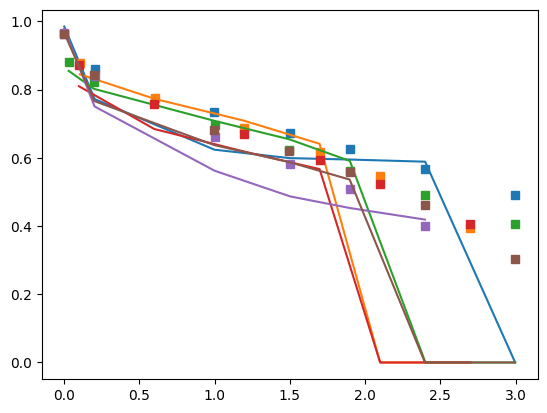

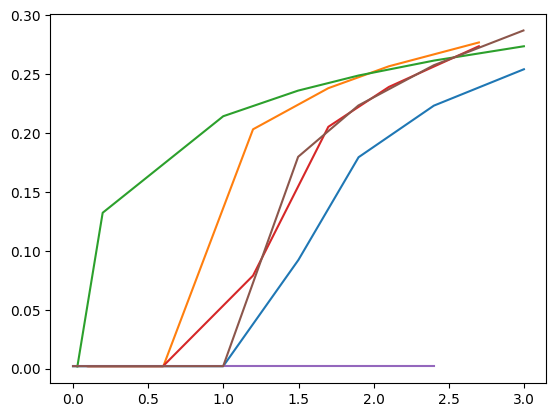

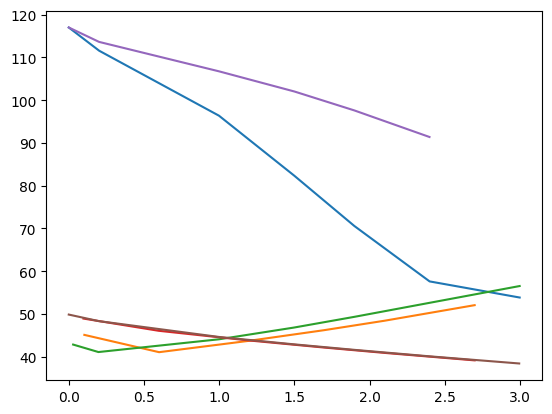

In [4]:
train_case_list = [1,2,3,4,5,6]
# test_case_list = [1,4,6]
def h(params, case_list=train_case_list): 
    fuel_cell = create_fuel_cell(params)
    return np.concatenate(
         [compute_ui_curve(fuel_cell, case) for case in case_list]
    )

exp_voltage_list = np.concatenate(
         [exp_data.loc[exp_data.case == case, 'U'] for case in train_case_list]
    )

model = cb.ParameterEstimationSteadyState(h, {'ECSA':80e3, 
                                              'i0-ca': 1.3e-3,
                                              'alpha-ca': 0.7,
                                              'ca-cl-thickness': 12e-6,
                                              'o2-diff-exponent': .8,
                                              'elec-resistance':10e-7,
                                              'gdl-eff-diff-ratio': 0.2,
                                              'memb-abs-constant': 1e-5, 
                                              'ionomer-thickness':2e-8,
                                              'wet-saturation': 0.354, 
                                              'ionomer-vol-fraction': 0.3,
                                              'gamma-c': 0.54,
                                              'S-cl-0': 20,
                                              'A_ch': 0, 
                                              'B_ch': 0.045, 
                                              'R-cl-exponent': 2.7,
                                              'critical-damkholer': 1.0, 
                                              'wet-transition': .25,
                                              'memb-thickness': 20e-6,
                                              'memb-cond-corr':1,
                                              'gdl-deltaT-ref': 8,
                                              'Kabs':1e-12, 
                                              'omega-PtO': 3000e3})

fuel_cell = create_fuel_cell(model.p)
for k, case in enumerate(train_case_list): 
    U_sim = compute_ui_curve(fuel_cell, case)
    plt.figure(1)
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, U_sim, 'C{}-'.format(k))
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, exp_data.loc[exp_data.case == case, 'U'].values, 'C{}s'.format(k))
    plt.figure(2)
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, fuel_cell.ca.gdl.water_saturation, 'C{}-'.format(k))
    plt.figure(3)
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, 1e7*fuel_cell.high_frequency_resistance(), 'C{}-'.format(k), label=case)


In [5]:
model.set_unknown_params(
        [
        ('memb-thickness', (1e-6, 30e-6), True, '$t_m$'), 
        ('elec-resistance', (30e-7,60e-7), True, '$R_{elec}$'),
        ('i0-ca', (1e-5,1e-2), False, '$ECSA$'),
        ('alpha-ca', (0.5, 1.0), True, 'alpha-ca'),
        # ('pt-loading', (0.2e-2, 0.4e-2), True, 'Pt load'),
        # ('pt-wt', (0.3,0.4), True, 'Pt wt'),
        # ('ic-ratio', (0.7,1.0), True, 'IC ratio'),
        ('gamma-c', (0.5,1), True, '$\gamma_c$'),
        ('ca-cl-thickness', (5e-6, 15e-6), True, '$t_{cl}$'),
        #('crossover-current', (0,2), True, '$i_x$'), 
        ('gdl-eff-diff-ratio', (0.1,0.6), True, '$t_{\mathrm{O}_2,eq}$'),  
        ('o2-diff-exponent', (0.5,4), True, '$m_{o2}$'),
        ('ionomer-thickness', (1.e-9,60.e-9), True, '$t_{ion}$'),
        #('A_ch', (1e-8, 10), False, '$A_{ch}$'),
        ('B_ch', (0, 1), True, '$B_{ch}$'),
        #('ionomer-vol-fraction', (0.15,0.4), True, r'$\varepsilon_{ion}$'),
        ('Kabs', (1e-14,1e-11), False, '$K_{l}$'),
        #('wet-saturtion', (0.1,0.5), True, '$s_{wet}$'),
        ('wet-transition', (0.1, 0.5), True, '$alpha_{wet}$'),
        #('critical-damkholer', (0.8,2), True, '$Da_{w,cr}$'),
        ('gdl-deltaT-ref', (0.1,5), True, '$k_{GDL}$'),
        #('R-ch-correction', (0.,1.), True, '$R_{ch}$'),
        ('R-cl-exponent', (1, 5), True, '$m_{R_{cl}}$'),
        ('S-cl-0', (1,200), True, '$R_{cl,0}$'),
        #('ionomer-vol-fraction', (0.1,.5), True, '$\epsilon_{ion}$'),
        ('E-act-ca', (30e3, 80e3), True, '$E_{act, ca}$'),
        ('omega-PtO', (0.1e6, 10e6), False, '$\omega_{PtO}$'),
        #('memb-cond-corr', (0.1,10), True,'$f_{mb}$'),
        #('memb-water-diff', (1e-10, 40e-10), True, '$D_{\lambda}$'),
        ('memb-abs-constant', (1e-7, 1e-4), False, '$k_{abs}$'),
        ]
    )


In [6]:

# cosPhi_med_ij, norm_s_i, S_med, S_std, S_med_i, S_std_i, S_n, n_valid = model.compute_global_sensitivity(t=0, m=8,  
#                                                                                                          check_samples=True,
#                                                                                                          y_exp=exp_voltage_list, 
#                                                                                                          res_limit=0.02)


In [7]:
# print('Number of valid samples: {:d}'.format(n_valid))
# fig1, ax1 = model.plot_global_sensitivity(xlabel_angle=45) 
# fig2, ax2 = model.plot_colinearity_map(xlabel_angle=45, cmap='Blues',figsize=(5,4))

# plt.show()

In [8]:
sol, p_est = model.estimate(exp_voltage_list, t=0, print_iterations=True, popsize=20, ftol=1e-5)
model.p.update({param: v for param, v in zip(model.p_i_name, p_est)})

differential_evolution step 1: f(x)= 0.0019899853896905638
------------------------------
RMSE : 44.6 mV
memb-thickness (1e-06, 3e-05) 1.42e-05
elec-resistance (3e-06, 6e-06) 3.52e-06
i0-ca (1e-05, 0.01) 3.94e-04
alpha-ca (0.5, 1.0) 8.27e-01
gamma-c (0.5, 1) 9.54e-01
ca-cl-thickness (5e-06, 1.5e-05) 6.03e-06
gdl-eff-diff-ratio (0.1, 0.6) 3.99e-01
o2-diff-exponent (0.5, 4) 7.38e-01
ionomer-thickness (1e-09, 6e-08) 1.63e-08
B_ch (0, 1) 4.24e-01
Kabs (1e-14, 1e-11) 4.49e-14
wet-transition (0.1, 0.5) 2.62e-01
gdl-deltaT-ref (0.1, 5) 1.02e+00
R-cl-exponent (1, 5) 2.37e+00
S-cl-0 (1, 200) 5.23e+01
E-act-ca (30000.0, 80000.0) 7.56e+04
omega-PtO (100000.0, 10000000.0) 1.78e+05
memb-abs-constant (1e-07, 0.0001) 6.37e-07
------------------------------
differential_evolution step 2: f(x)= 0.0015123655724555516
------------------------------
RMSE : 38.9 mV
memb-thickness (1e-06, 3e-05) 1.71e-05
elec-resistance (3e-06, 6e-06) 5.04e-06
i0-ca (1e-05, 0.01) 3.07e-04
alpha-ca (0.5, 1.0) 8.39e-01
gamma-

In [9]:
""""
------------------------------
differential_evolution step 303: f(x)= 0.0002924493040855187
------------------------------
RMSE : 17.1 mV
memb-thickness (1e-06, 3e-05) 1.49e-05
elec-resistance (3e-06, 6e-06) 5.99e-06
i0-ca (1e-05, 0.01) 1.01e-03
alpha-ca (0.5, 1.0) 9.26e-01
gamma-c (0.5, 1) 9.90e-01
ca-cl-thickness (5e-06, 1.5e-05) 1.25e-05
gdl-eff-diff-ratio (0.1, 0.6) 4.63e-01
o2-diff-exponent (0.5, 4) 1.36e+00
ionomer-thickness (1e-09, 6e-08) 7.52e-09
B_ch (0, 1) 5.31e-01
Kabs (1e-14, 1e-11) 1.24e-14
wet-transition (0.1, 0.5) 1.55e-01
gdl-deltaT-ref (0.1, 5) 4.00e+00
R-cl-exponent (1, 5) 1.58e+00
S-cl-0 (1, 200) 2.39e+01
ionomer-vol-fraction (0.1, 0.5) 2.17e-01
E-act-ca (30000.0, 80000.0) 6.70e+04
memb-abs-constant (1e-07, 0.0001) 9.14e-07
------------------------------
"""

'"\n------------------------------\ndifferential_evolution step 303: f(x)= 0.0002924493040855187\n------------------------------\nRMSE : 17.1 mV\nmemb-thickness (1e-06, 3e-05) 1.49e-05\nelec-resistance (3e-06, 6e-06) 5.99e-06\ni0-ca (1e-05, 0.01) 1.01e-03\nalpha-ca (0.5, 1.0) 9.26e-01\ngamma-c (0.5, 1) 9.90e-01\nca-cl-thickness (5e-06, 1.5e-05) 1.25e-05\ngdl-eff-diff-ratio (0.1, 0.6) 4.63e-01\no2-diff-exponent (0.5, 4) 1.36e+00\nionomer-thickness (1e-09, 6e-08) 7.52e-09\nB_ch (0, 1) 5.31e-01\nKabs (1e-14, 1e-11) 1.24e-14\nwet-transition (0.1, 0.5) 1.55e-01\ngdl-deltaT-ref (0.1, 5) 4.00e+00\nR-cl-exponent (1, 5) 1.58e+00\nS-cl-0 (1, 200) 2.39e+01\nionomer-vol-fraction (0.1, 0.5) 2.17e-01\nE-act-ca (30000.0, 80000.0) 6.70e+04\nmemb-abs-constant (1e-07, 0.0001) 9.14e-07\n------------------------------\n'

(10, 13)
(10, 12)
(10, 14)
(10, 13)
(10, 12)
(10, 13)


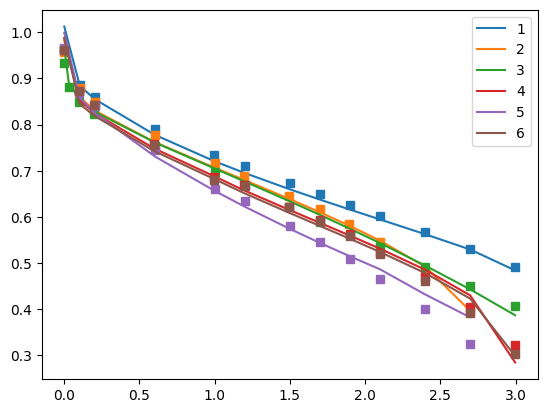

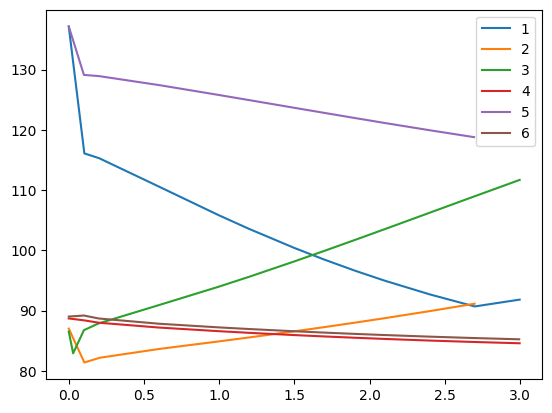

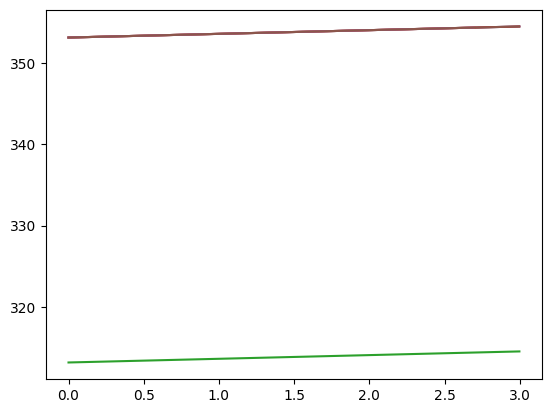

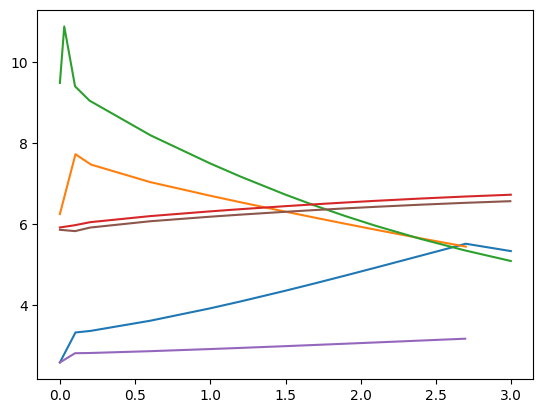

In [11]:
exp_data = pd.read_csv(f'../data/goshtasbi_et_al_2020/Goshtasbi2020-tn.csv', sep=';', decimal=',')
exp_data['case'] = exp_data[['T_stack', 'rh_ca', 'rh_an', 'st_ca', 'st_an', 'p_ca_out']].sum(axis=1)
case_list = [1,2,3,4,5,6]
exp_data['case'] = exp_data['case'].map(dict(zip(exp_data['case'].unique(),case_list)))

fuel_cell = create_fuel_cell(model.p)
for k, case in enumerate(case_list): 
    U_sim = compute_ui_curve(fuel_cell, case)
    plt.figure(1)
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, U_sim, 'C{}-'.format(k), label=case)
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, exp_data.loc[exp_data.case == case, 'U'].values, 'C{}s'.format(k))
    plt.legend()
    plt.figure(2)
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, 1e7*fuel_cell.high_frequency_resistance(), 'C{}-'.format(k), label=case)

    plt.legend()
    plt.figure(3)
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, fuel_cell.ca.cl.temperature, 'C{}-'.format(k), label=case)
    
    plt.figure(4)
    print(np.shape(fuel_cell.membrane.water_balance_model.water_content_profile))
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, fuel_cell.membrane.water_content, 'C{}-'.format(k), label=case)
   
